In [8]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import optax
import diffrax
from seaborn import kdeplot
import wandb
from ot.lp import wasserstein_1d
import argparse
import pickle

from triangular_transport.flows.flow_trainer import (
    NNTrainer,
)

from triangular_transport.flows.interpolants import (
    linear_interpolant,
    linear_interpolant_der,
    trig_interpolant,
    trig_interpolant_der,
    sigmoid_interpolant,
    sigmoid_interpolant_der,
)
from triangular_transport.flows.loss_functions import vec_field_loss
from triangular_transport.networks.flow_networks import MLP
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import (
    standard_gaussian_reference_sampler,
    gaussian_reference_sampler
)
plt.style.use("ggplot")

In [12]:
# ys = np.random.uniform(low=-3.0, high=3.0, size=(10000, 1))
ys = 2.0 * np.ones((5000000, 1))
us = np.tanh(ys) + np.random.gamma(shape=1.0, scale=0.3, size=(5000000, 1))
data = np.hstack([ys, us])

<Axes: ylabel='Density'>

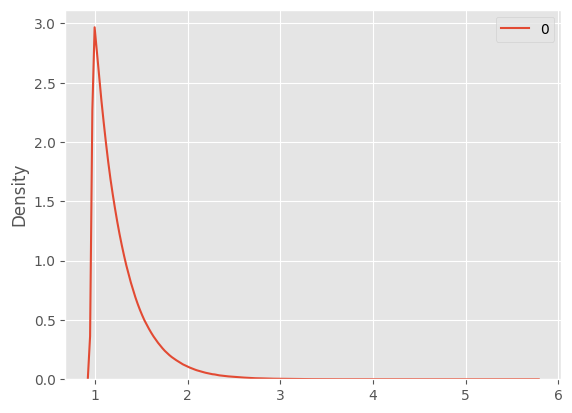

In [13]:
kdeplot(us)

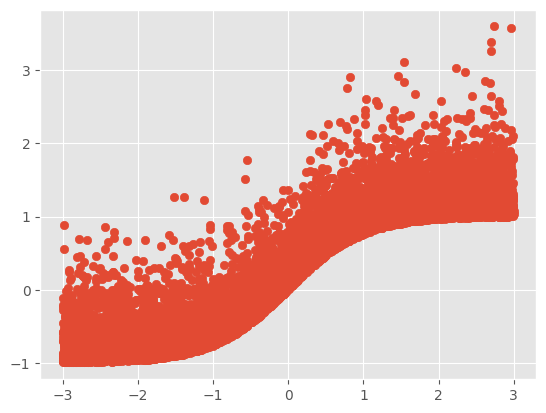

In [57]:
plt.scatter(ys, us)

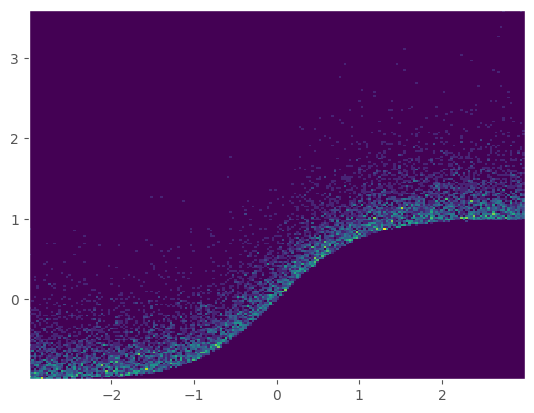

In [58]:
plt.hist2d(ys.squeeze(), us.squeeze(), bins=200);

<Axes: ylabel='Density'>

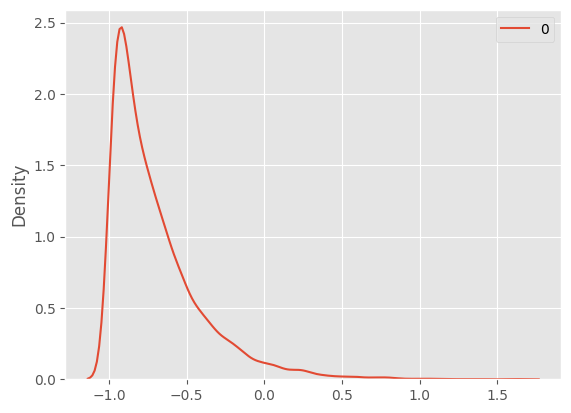

In [7]:
kdeplot(us)

In [8]:
key1 = random.key(2)
epochs = 400
x1_data = data.copy()
train_dim = 10000
batch_size = 2048
# batch_size = hyperparams["batch_size"]
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 10000
yu_dimension = (1, 1)
dim = yu_dimension[0] + yu_dimension[1]
# hidden_layer_list = [256] * 4 if train_dim < 8000 else [1024] * 8
hidden_layer_list = [512] * 6
# hidden_layer_list = [256] * 4
# hidden_layer_list = [1024] * 8
target_data = x1_data[:train_dim, :]
model = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list,
    num_layers=len(hidden_layer_list) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=400,
    decay_steps=steps,
    end_value=1e-5,
)

optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adamw(schedule)
)

interpolant = linear_interpolant
interpolant_der = linear_interpolant_der
interpolant_args = {"t": None, "x1": None, "x0": None}

trainer = NNTrainer(
    target_density=None,
    model=model,
    optimizer=optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=standard_gaussian_reference_sampler,
    loss=vec_field_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
    # reference_sampler_args=reference_sampler_args,
)

trainer.train(
    train_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  3%|▎         | 68/2000 [00:03<01:05, 29.44it/s] 

step = 0, train_loss = -0.04112924635410309


100%|██████████| 2000/2000 [00:06<00:00, 330.51it/s]

step = 1999, train_loss = -1.1296970844268799


In [9]:
cond_vals = [-3, 0, 2]
nsamples = 10000
cond_samples = trainer.conditional_sample(
    cond_values=cond_vals,
    nsamples=nsamples,
    u0_cond=None,
)

100%|██████████| 3/3 [00:01<00:00,  1.91it/s]


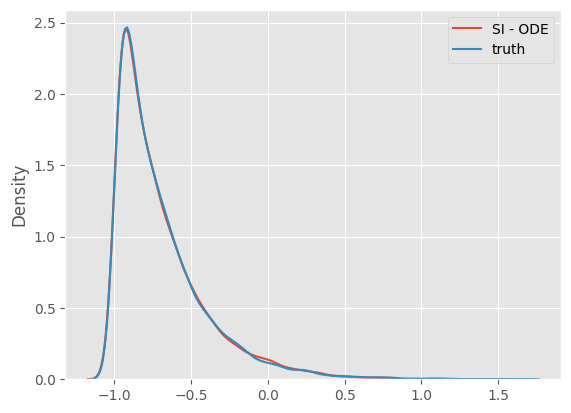

In [10]:
kdeplot(cond_samples[0][:, 1], label="SI - ODE")
kdeplot(us.squeeze(), label="truth")
plt.legend()

In [14]:
wasserstein_1d(np.asarray(cond_samples[0][:, 1]), us.squeeze()) / wasserstein_1d(us.squeeze(), np.random.randn(10000))

np.float64(0.0040564354523652925)

In [12]:
wasserstein_1d(us.squeeze(), np.random.randn(10000))

np.float64(0.8620968227008357)

In [13]:
wasserstein_1d(np.asarray(cond_samples[1][:, 1]), us.squeeze())

np.float64(0.7337744338467007)

In [ ]:
ys = -3.0 * np.ones((100000, 1))
us = np.tanh(ys) + np.random.gamma(shape=1.0, scale=0.3, size=(100000, 1))
data = np.hstack([ys, us])
np.save("samps_3.npy", us)

: 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from seaborn import kdeplot
plt.style.use("ggplot")

In [32]:
si_array = np.zeros((10, 23))
for i in range(10):
    si_array[i, :] = np.load(f"converge_results_0/run_{i:02d}/nn_conv_wd_{i}.npy")
wd_ode = np.mean(si_array, axis=0)

In [39]:
wd_mcmc

array([1.31773429e+00, 1.25663275e+00, 8.30660124e-01, 3.71425903e-01,
       1.31926726e-01, 4.91257848e-02, 1.10386454e-01, 3.06559886e-02,
       7.44929614e-03, 1.22221678e-02, 6.13078549e-03, 1.24300169e-03,
       8.60951377e-04, 3.32464107e-04, 6.77595560e-04, 4.68118115e-04,
       4.58026054e-04, 3.14006187e-04, 3.32023511e-04, 3.60594614e-04,
       2.56081906e-04, 3.06494830e-04, 2.64875922e-04])

In [40]:
wd_ode

array([0.20892708, 0.26476602, 0.13824718, 0.15857568, 0.13091532,
       0.08166781, 0.03537773, 0.01898733, 0.01461714, 0.00860026,
       0.00555192, 0.00522072, 0.00461548, 0.00426096, 0.00395703,
       0.00421104, 0.00386138, 0.00382928, 0.0039312 , 0.00393784,
       0.00391794, 0.00391974, 0.00390798])

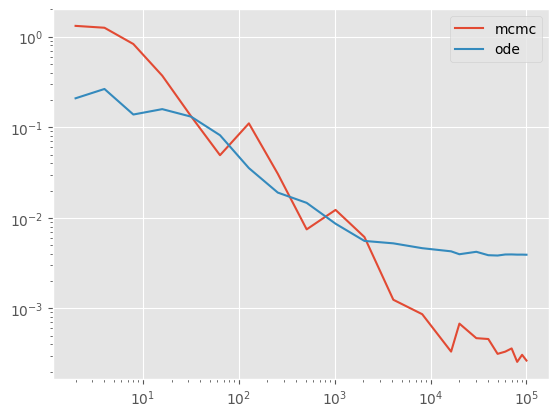

In [33]:
wd_mcmc = np.load("mcmc_results_0/avg_wd_mcmc.npy")
sample_nos = np.load("sample_no_list.npy")
plt.plot(sample_nos, wd_mcmc, label="mcmc")
plt.plot(sample_nos, wd_ode, label="ode")
plt.xscale("log")
plt.yscale("log")
plt.legend()

In [34]:
mcmc_samps0 = np.load("mcmc_results_0/mcmc_samps.npy")
samps0 = np.load("samps_0.npy")

In [35]:
samps0.shape

(100000, 1)

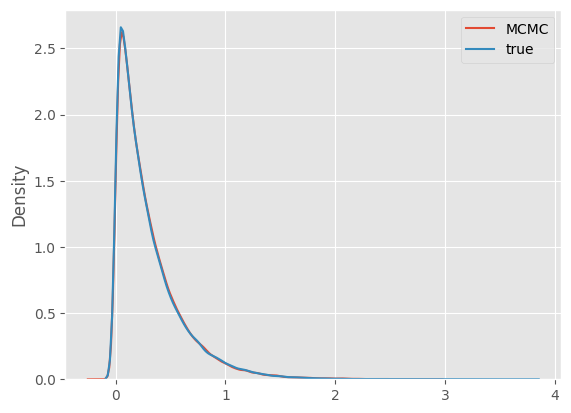

In [38]:
kdeplot(np.vstack(mcmc_samps0[1]).squeeze(), label="MCMC")
kdeplot(samps0.squeeze(), label="true")
plt.legend()